**Anomaly detection in timeseries:**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams["figure.figsize"] = (9,6)

Read the data:
- This is real-life data on CPU utilization of an EC2 instance in the AWS cloud. Data was recorded every 5 minutes, starting Feb 14th at 2.30pm. The dataset contains 4032 data points. 

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/data/realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv")
df.head()

,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


from the data labels found here: [labels](https://github.com/numenta/NAB/blob/master/labels/combined_labels.json), anomalies were found at these timestamps:
- [
        "2014-02-26 22:05:00",
        "2014-02-27 17:15:00"
    ]

In [5]:
anomalies_timestamp = [
        "2014-02-26 22:05:00",
        "2014-02-27 17:15:00"
    ]

In [4]:
# convert to timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


In [9]:
# add an anomaly label
df['is_anomaly'] = 1 # by default setting 1 (not anomaly), -1 is anomaly

for each in anomalies_timestamp:
    df.loc[df['timestamp']==each,'is_anomaly'] = -1
df.head()

,timestamp,value,is_anomaly
0,2014-02-14 14:30:00,0.132,1
1,2014-02-14 14:35:00,0.134,1
2,2014-02-14 14:40:00,0.134,1
3,2014-02-14 14:45:00,0.134,1
4,2014-02-14 14:50:00,0.134,1


In [10]:
df.loc[df['is_anomaly']==-1]

,timestamp,value,is_anomaly
3547,2014-02-26 22:05:00,2.344,-1
3777,2014-02-27 17:15:00,0.602,-1


In [11]:
anomaly_df = df.loc[df['is_anomaly']==-1]
inlier_df = df.loc[df['is_anomaly']==1]

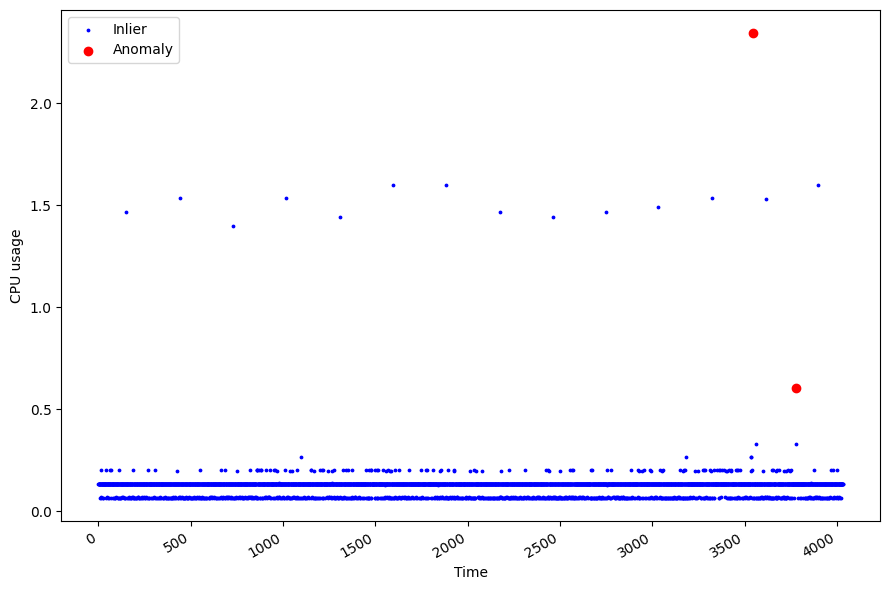

In [12]:
fig, ax = plt.subplots()

ax.scatter(inlier_df.index, inlier_df['value'], color='blue', s=3, label='Inlier')
ax.scatter(anomaly_df.index, anomaly_df['value'], color='red', label='Anomaly')
ax.set_xlabel('Time')
ax.set_ylabel('CPU usage')
ax.legend(loc=2)

plt.grid(False)
fig.autofmt_xdate()
plt.tight_layout()

**Baseline: Mean absolute deviation (MAD)**
- Idea: When data is normally distributed, we can reasonably conclude that points at each tail are outliers
        - We use the z score to identify these, remember: Z score = (X-mean)/(standard deviation)
        - So points close to the mean have a z score of about zero. and the further away, the more the z score increases
        - e.g. we can set a threshold of 3 (z score), and points greater or less than this threshold are considered outliers
        - But, because outliers affect the mean and we use the mean to compute the z score, we are affecting the z score 
- Robust Z score method hence uses the median instead of the mean (mean is affected by outliers)
  - MAD = median(|xi - xmedian|) => median of the absolute difference between the values in the sample and the median of the sample
  - MAD is sort of our new standard deviation but one that uses the median this time
    - new z score now computed as 0.6745(xi - xmedian)/MAD. 
      - why scale by 0.6745 => to make the data comparable to the z score mad
      - robust z score only works if the data is close to a normal distribution
      - need to ensure mad is not equaal to 0 (cant divide by zero) -> happens when more than 50% of the data has the same value

In [13]:
# exploring the data: remember that for the robust mad to work - data needs to follow a normal distribution
# also, we need the data having different values works for us if we don't have a case where more than 50% of the data has the same value, so as to avoid
# having a dividend value of 0

In [15]:
df['value'].median()

np.float64(0.134)

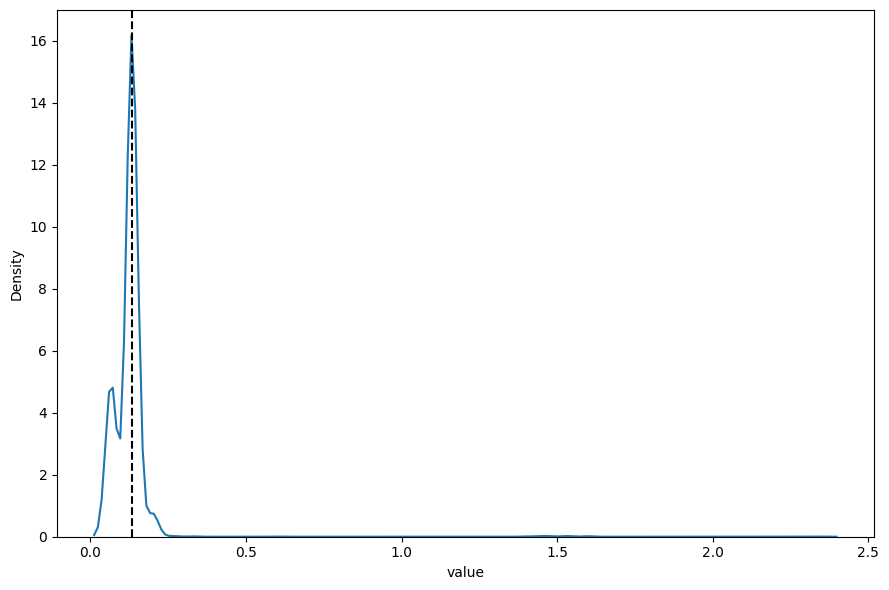

In [14]:
import seaborn as sns

sns.kdeplot(df['value'])
plt.grid(False)
plt.axvline(0.134, 0, 1, c='black', ls='--')
plt.tight_layout()

Comments:
- skewed distribution
- a big portion of the data falls right on the median: 0.134 (bad thing because sort of tends towards a dividend of zero)

In [16]:
from scipy.stats import median_abs_deviation

mad = median_abs_deviation(df['value'])
median = np.median(df['value'])

print(mad)
print(median)

def compute_robust_z_score(x):
    return 0.6745*(x-median)/mad

0.0020000000000000018
0.134


mad is so small so probably any point above the median gets flagged as an outlier...

In [17]:
df['z-score'] = df['value'].apply(compute_robust_z_score)
df.head()

,timestamp,value,is_anomaly,z-score
0,2014-02-14 14:30:00,0.132,1,-0.6745
1,2014-02-14 14:35:00,0.134,1,0.0000
2,2014-02-14 14:40:00,0.134,1,0.0000
3,2014-02-14 14:45:00,0.134,1,0.0000
4,2014-02-14 14:50:00,0.134,1,0.0000


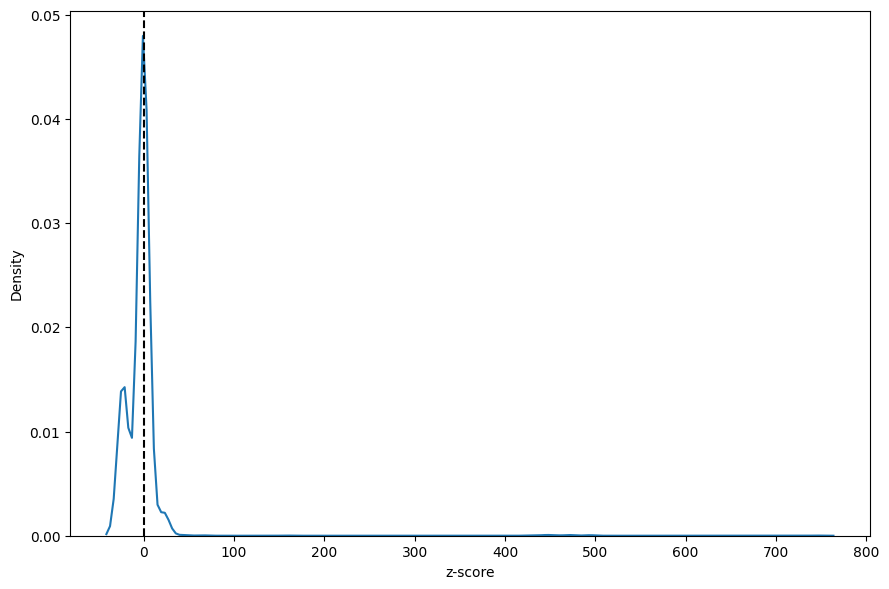

In [53]:
sns.kdeplot(df['z-score'])
plt.grid(False)
plt.axvline(0.134, 0, 1, c='black', ls='--')
plt.tight_layout()

as can be seen from the z score above, not so easy to get outliers as the data isn't well spread out

In [50]:
# determine if it is an anomaly ( using a threshold of 3.5 in this case)
df['baseline'] = 1

df.loc[df['z-score'] >= 3.5, 'baseline'] = -1
df.loc[df['z-score'] <= -3.5, 'baseline'] = -1

Evaluation:

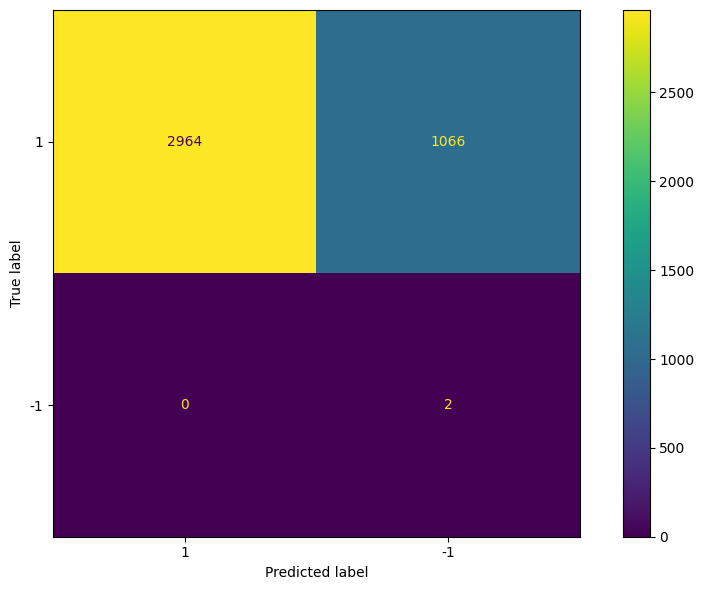

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# plot the confusion matrix
cm = confusion_matrix(df['is_anomaly'], df['baseline'], labels=[1,-1])
disp_cm = ConfusionMatrixDisplay(cm,display_labels=[1,-1])
disp_cm.plot();

plt.grid(False)
plt.tight_layout()

so the 3.5 setting gets us lots of false positives.

Question:
- would this work if we altered the distribution - tried to make it normal by using the box-cox transformations


In [20]:
df2 = df.copy()

In [21]:
df2.head()

,timestamp,value,is_anomaly,z-score,baseline
0,2014-02-14 14:30:00,0.132,1,-0.6745,1
1,2014-02-14 14:35:00,0.134,1,0.0000,1
2,2014-02-14 14:40:00,0.134,1,0.0000,1
3,2014-02-14 14:45:00,0.134,1,0.0000,1
4,2014-02-14 14:50:00,0.134,1,0.0000,1


In [22]:
from scipy.stats import boxcox

In [23]:
transformed_data, best_lambda = boxcox(df2['value'])

In [25]:
df2['value_transformed'] = transformed_data

In [26]:
df2['value_transformed'].median()

np.float64(-2.4521859320892077)

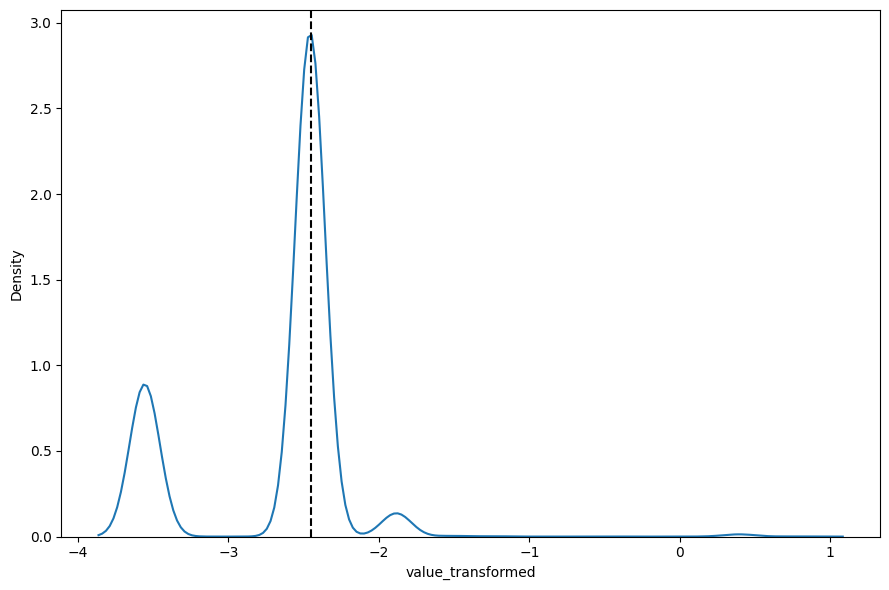

In [27]:
sns.kdeplot(df2['value_transformed'])
plt.grid(False)
plt.axvline(-2.4521859320892077, 0, 1, c='black', ls='--')
plt.tight_layout()

In [28]:
mad = median_abs_deviation(df2['value_transformed'])
median = np.median(df2['value_transformed'])

print(mad)
print(median)

0.02175050613676488
-2.4521859320892077


In [29]:
df2['z-score2'] = df2['value_transformed'].apply(compute_robust_z_score)

In [56]:
# determine if it is an anomaly ( using a threshold of 3.5 in this case)
df2['baseline'] = 1

df2.loc[df2['z-score2'] >= 55.5, 'baseline'] = -1
df2.loc[df2['z-score2'] <= -55.5, 'baseline'] = -1

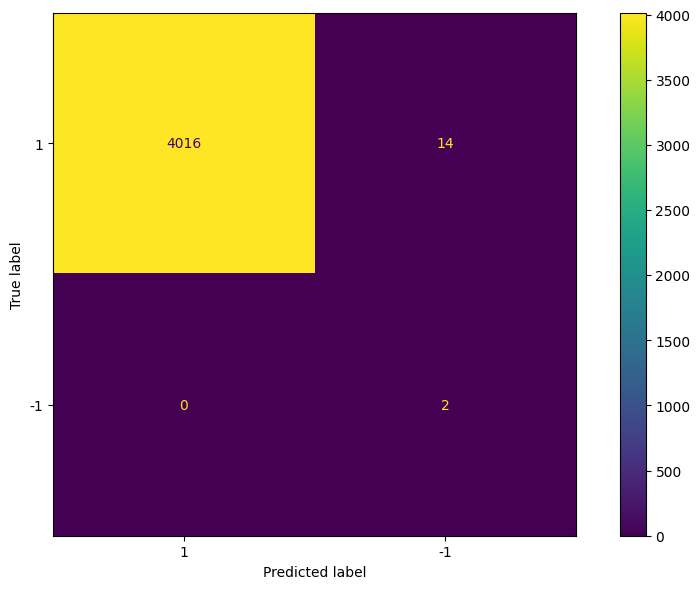

In [57]:
# plot the confusion matrix
cm = confusion_matrix(df2['is_anomaly'], df2['baseline'], labels=[1,-1])
disp_cm = ConfusionMatrixDisplay(cm,display_labels=[1,-1])
disp_cm.plot();

plt.grid(False)
plt.tight_layout()

not so bad anymore -  so can do box-cox and a bit of tuning to search for the outliers...

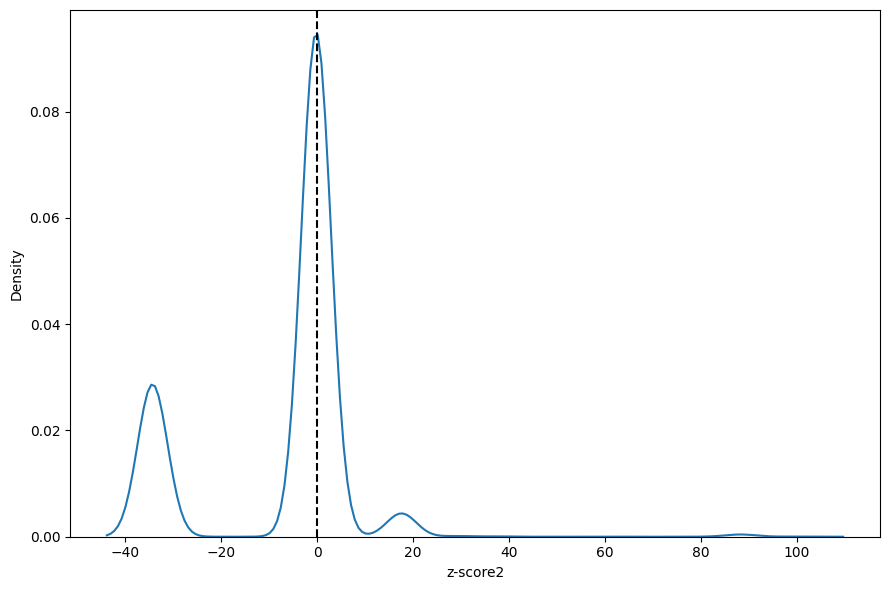

In [58]:
sns.kdeplot(df2['z-score2'])
plt.grid(False)
plt.axvline(0, 0, 1, c='black', ls='--')
plt.tight_layout()

**Isolation Forest:**
- Tree based algorithm for anomaly detection
  - Partitions the data to isolate points
    - Many partitions - means the point is an inlier
    - Few partitions - means the point is an outlier
  - Core idea: outliers are easier to isolate than normal points
    - normal points sit in dense clumps
    - outliers sit alone or near the edge
    - The isolation forest algorithm measures how quickly a point get isolated
  - Conceptual implementation:
    - Take data and:
      - Pick a feature at random
      - Pick a cut value at random within that feature\s range
      - Split the data into two groups
      - Repeat the process recursively
    - Creates a random decision tree but:
      - no target variable
      - no optimization
      - no best split
      - just random slicing
    - As tree grows:
      - some points get separated very early
      - others stay grouped for a long time
    - For each point, we count: How many splits did it taake until this point was alone - number is called the **path length**
    - Short path length -> easy to isolate -> likely an outlier
    - Long path length -> hard to isolate -> likely normal
    - Algorithm is helped by its randomness and the fact that we have multiple trees (forest)
    - We average the results of all the trees in the forest
- Makes no assumptions about the data

In [59]:
from sklearn.ensemble import IsolationForest

In [60]:
# split the data into a test and training set.
# we want to see if our trained isolation forest is able to pick up the anomaly in the test set

train = df[:3550]
test = df[3550:]

In [75]:
# since we know there's one anomaly in the training set- we set the contamination accordingly - which is the ratio of the anomalies to the entire dataset
contamination = 1/len(train)

iso_forest = IsolationForest(contamination=contamination, random_state=42)

X_train = train['value'].values.reshape(-1,1)

iso_forest.fit(X_train)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.00028169014084507044
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [76]:
preds_iso_forest = iso_forest.predict(test['value'].values.reshape(-1,1))

evaluation:

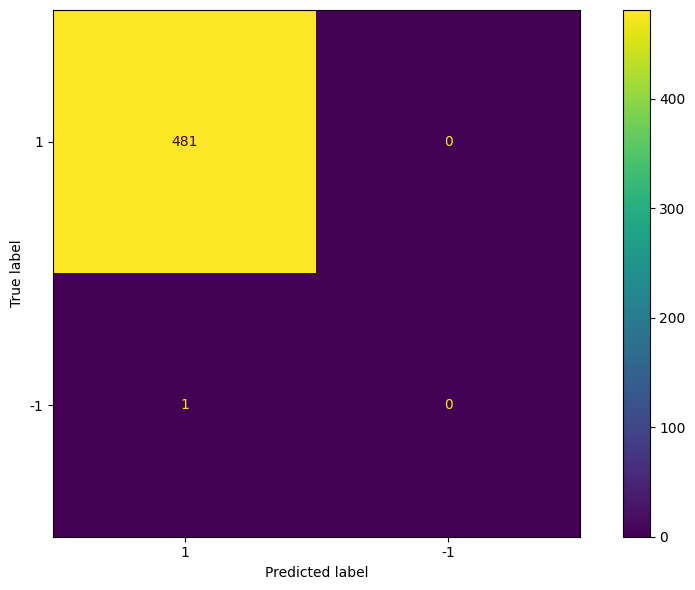

In [78]:
# plot the confusion matrix

cm = confusion_matrix(test['is_anomaly'], preds_iso_forest, labels=[1,-1])
disp_cm = ConfusionMatrixDisplay(cm, display_labels=[1,-1])
disp_cm.plot();
plt.grid(False)
plt.tight_layout()

the model fails when we use predict.....but what if we inspect the raw output scores and set the threshold ourselves

inspect the scores on both the test and training sets...

In [94]:
train[train['is_anomaly']==-1]

,timestamp,value,is_anomaly,z-score,baseline
3547,2014-02-26 22:05:00,2.344,-1,745.3225,-1


In [83]:
train.iloc[3547]

timestamp     2014-02-26 22:05:00
value                       2.344
is_anomaly                     -1
z-score                  745.3225
baseline                       -1
Name: 3547, dtype: object

In [106]:
train_scores = iso_forest.decision_function(X_train)
test_scores = iso_forest.decision_function(test['value'].values.reshape(-1,1))

In [87]:
train_scores[3547]

np.float64(-0.002288609340699077)

need to check if there's more points with a score below this..

In [97]:
train_scores[train_scores<train_scores[3547]]

array([], dtype=float64)

no point - so the outlier had the lowest score

Higher scores - more normal, lower scores - more isolated/anomalous

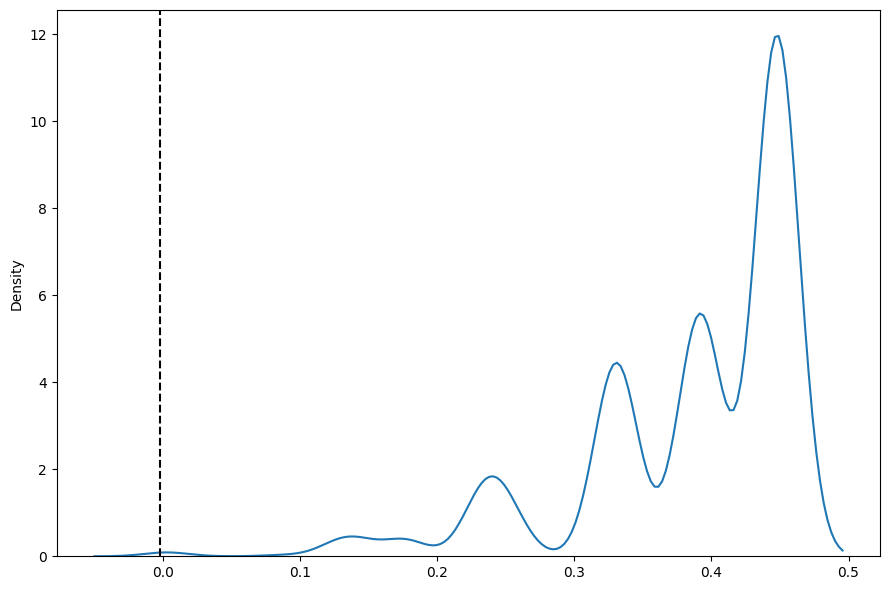

In [88]:
sns.kdeplot(train_scores)
plt.grid(False)
plt.axvline(train_scores[3547], 0, 1, c='black', ls='--')
plt.tight_layout()

above plot shows the scores and the vertical line is the score of the known outlier...

look at the test scores now...

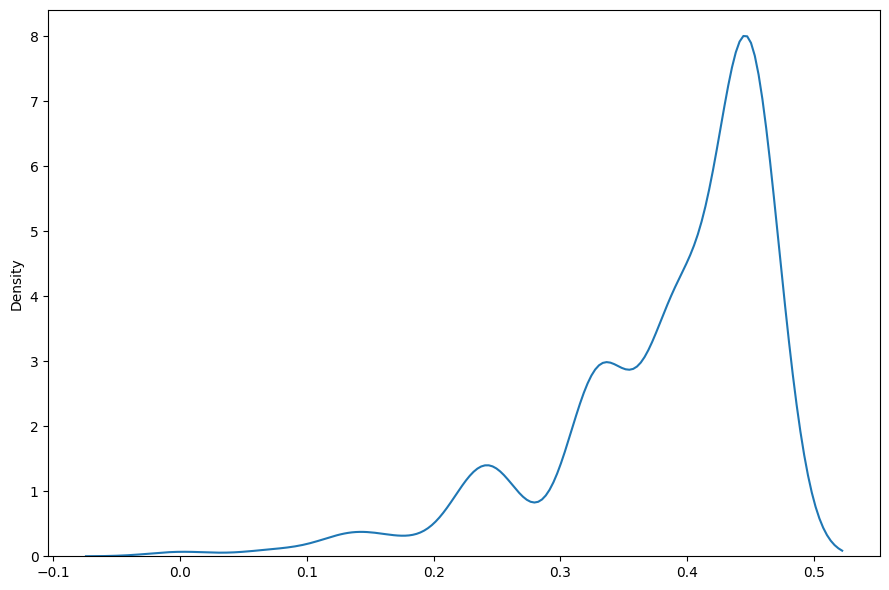

In [89]:
sns.kdeplot(test_scores)
plt.grid(False)
# plt.axvline(train_scores[3547], 0, 1, c='black', ls='--')
plt.tight_layout()

before looking at the score corresponding to this point, i'd say the that id put the threshold at 0 and points below that would be my anomalies...

In [95]:
test

,timestamp,value,is_anomaly,z-score,baseline
3550,2014-02-26 22:20:00,0.134,1,0.0000,1
3551,2014-02-26 22:25:00,0.066,1,-22.9330,-1
3552,2014-02-26 22:30:00,0.132,1,-0.6745,1
3553,2014-02-26 22:35:00,0.134,1,0.0000,1
3554,2014-02-26 22:40:00,0.132,1,-0.6745,1
...,...,...,...,...,...
4027,2014-02-28 14:05:00,0.132,1,-0.6745,1
4028,2014-02-28 14:10:00,0.134,1,0.0000,1
4029,2014-02-28 14:15:00,0.134,1,0.0000,1
4030,2014-02-28 14:20:00,0.134,1,0.0000,1


In [91]:
test[test['is_anomaly']==-1]

,timestamp,value,is_anomaly,z-score,baseline
3777,2014-02-27 17:15:00,0.602,-1,157.833,-1


In [107]:
test_scores[3777-3550] # cuz starting index for the test dataset is 3550

np.float64(0.06096571170407339)

need to check and see if there's any points with a score below this

In [98]:
test_scores[test_scores < test_scores[3777-3550]]

array([1.14295074e-03, 6.44860338e-07])

2 more points

plot these

In [110]:
test2 = test.copy()
test2['iso_scores'] = test_scores
test2['baseline2'] = 1

In [111]:
test2.loc[test2['iso_scores']<=0.06096571170407339,'baseline2'] = -1

In [118]:
anomaly_df2 = test2.loc[test2['baseline2'] == -1]
inlier_df2 = test2.loc[test2['baseline2'] == 1]

In [119]:
test2[test2['baseline2']==-1]

,timestamp,value,is_anomaly,z-score,baseline,iso_scores,baseline2
3614,2014-02-27 03:40:00,1.532,1,471.4755,-1,1.142951e-03,-1
3777,2014-02-27 17:15:00,0.602,-1,157.8330,-1,6.096571e-02,-1
3898,2014-02-28 03:20:00,1.600,1,494.4085,-1,6.448603e-07,-1


In [120]:
anomaly_df2

,timestamp,value,is_anomaly,z-score,baseline,iso_scores,baseline2
3614,2014-02-27 03:40:00,1.532,1,471.4755,-1,1.142951e-03,-1
3777,2014-02-27 17:15:00,0.602,-1,157.8330,-1,6.096571e-02,-1
3898,2014-02-28 03:20:00,1.600,1,494.4085,-1,6.448603e-07,-1


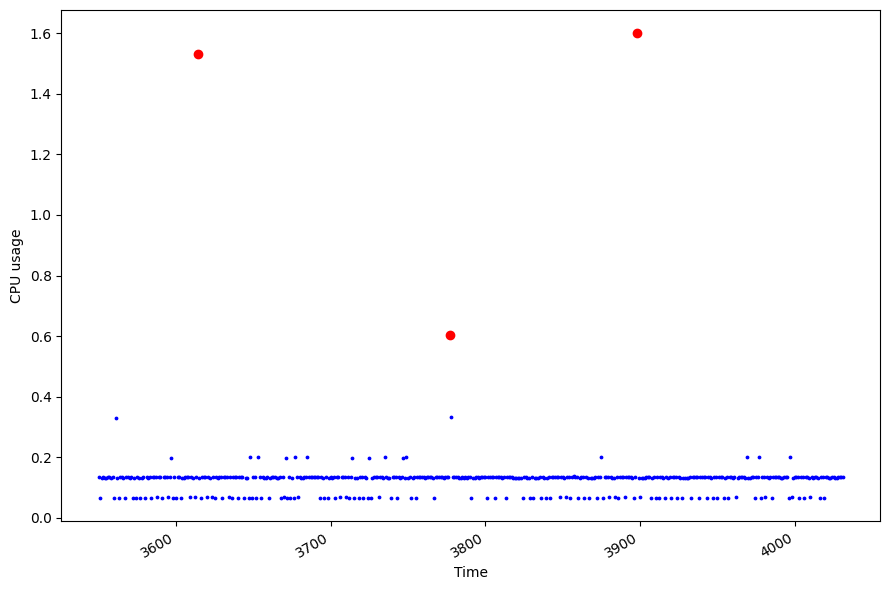

In [121]:
fig, ax = plt.subplots()

ax.scatter(inlier_df2.index, inlier_df2['value'], color='blue', s=3, label='Inlier')
ax.scatter(anomaly_df2.index, anomaly_df2['value'], color='red', label='Anomaly')
ax.set_xlabel('Time')
ax.set_ylabel('CPU usage')
# ax.legend(loc=2)

plt.grid(False)
fig.autofmt_xdate()
plt.tight_layout()

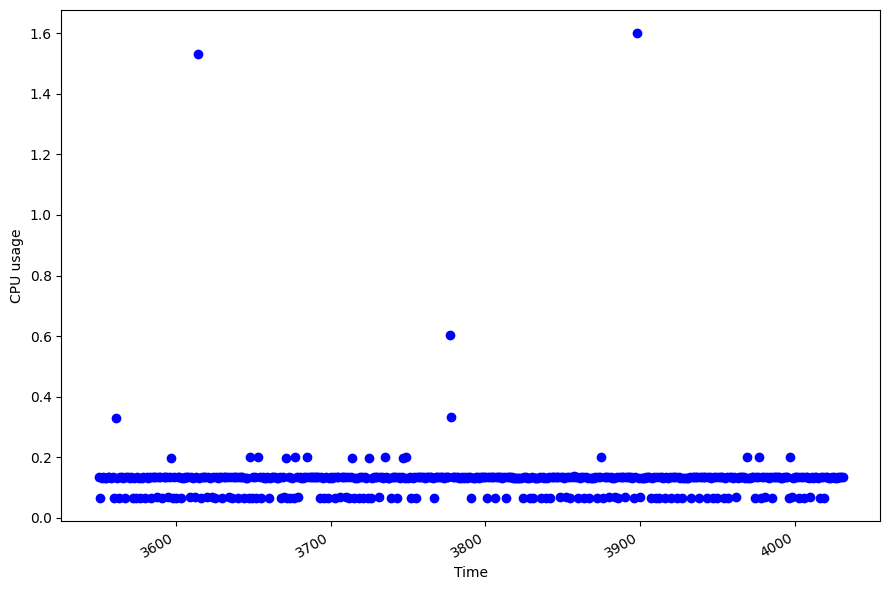

In [122]:
fig, ax = plt.subplots()

ax.scatter(test2.index, test2['value'], color='blue')
# ax.scatter(anomaly_df2.index, anomaly_df2['value'], color='red', label='Anomaly')
ax.set_xlabel('Time')
ax.set_ylabel('CPU usage')
# ax.legend(loc=2)

plt.grid(False)
fig.autofmt_xdate()
plt.tight_layout()

Model seems right, when taken out of context and looking at the test set alone these 3 values look like outliers...

**looking at the decision function is important with the isolation forest algorithm**

**Local Outlier Factor:**
- Unsupervised method for anomaly detection
- Core idea: A point is an outlier if it is much less crowded than its neighbors
- LOF only cares about local neighborhoods | LOF doesn't care about the global center or the overall density or the shape of the dataset - only local neighborhoods. So, dense regions can exist far from the center, sparse regions can near it. Outliers are defined locally not globally
- Pick 'how local' means (k-neighbors) | k = number of neighbors | typical values: 10-50, 
- for each point we are determining how crowded/how lonely it is compared to its neighbors
- so choose a value of k - appropriately so that its big enough to see a neighborhood, yet small enough to stay local
- This choice of k defines: who counts as 'around you'
  - So, for each point:
    - find its k nearest neighbors
    - measure how close those neighbors are
  - Intuition: neighbors close together -> dense area | neighbors spread out -> sparse area
    - This gives each point a local density estimate
    - For each point - compute its density and also compute the densities of its neighbors
    - take the ratio | 
       - Interpretation:
         - Density eq or approx to neighbors - normal
         - Density << neighbors -> outlier
         - Density > neighbors -> normal

- Intuition:
  - Compare the local density of a point to that of its neighbors
  - If the density is smaller, then the point is isolated, so its an outlier
  - This is all based on a metric called the reachability distance
    - reachability_distance_k (A,B) = max {k-distance(B), d(A,B)}

  - Local outlier factor: if LOF is close to 1 or is smaller than 1: inlier, LOF > 1: outlier

In [124]:
from sklearn.neighbors import LocalOutlierFactor

In [125]:
lof = LocalOutlierFactor(contamination=contamination, novelty=True)
lof.fit(X_train)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",20
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.00028169014084507044
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [127]:
preds_lof = lof.predict(test['value'].values.reshape(-1,1))

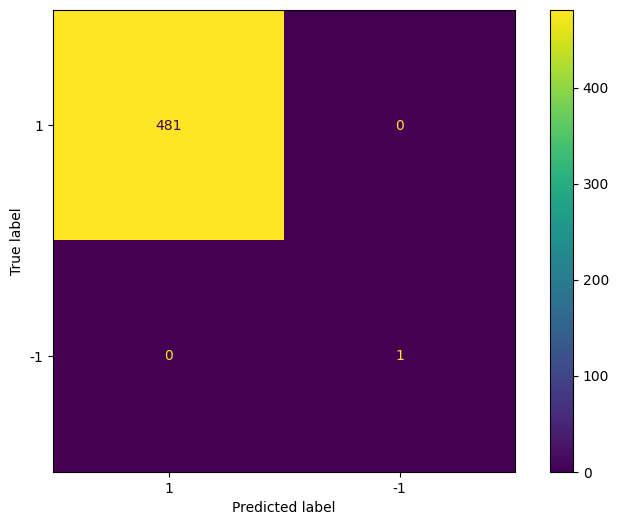

In [128]:
# plot the confusion matrix

cm = confusion_matrix(test['is_anomaly'], preds_lof, labels=[1,-1])
disp_cm = ConfusionMatrixDisplay(cm, display_labels=[1,-1])
disp_cm.plot()

Local outlier factor successfully identifies the anomaly in the dataset

In [129]:
preds_scores = lof.decision_function(test['value'].values.reshape(-1,1))

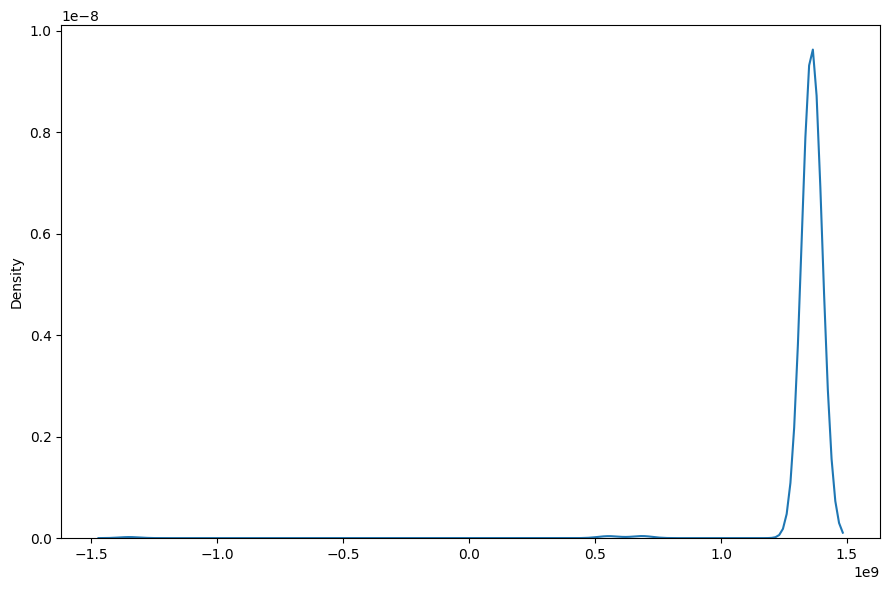

In [130]:
sns.kdeplot(preds_scores)
plt.grid(False)
# plt.axvline(train_scores[3547], 0, 1, c='black', ls='--')
plt.tight_layout()

In [134]:
preds_scores[3777-3550]

np.float64(-1348526596.097324)

In [136]:
sorted(preds_scores.tolist())

[-1348526596.097324,
 541473418.2558596,
 567373418.4525517,
 680623352.1166109,
 692523353.3933283,
 1342173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.1808887,
 1361173424.18088

outlier had the lowest score...low density values point to sparsity hence outliers...

In [132]:
test[test['is_anomaly']==-1]

,timestamp,value,is_anomaly,z-score,baseline
3777,2014-02-27 17:15:00,0.602,-1,157.833,-1


In [133]:
test

,timestamp,value,is_anomaly,z-score,baseline
3550,2014-02-26 22:20:00,0.134,1,0.0000,1
3551,2014-02-26 22:25:00,0.066,1,-22.9330,-1
3552,2014-02-26 22:30:00,0.132,1,-0.6745,1
3553,2014-02-26 22:35:00,0.134,1,0.0000,1
3554,2014-02-26 22:40:00,0.132,1,-0.6745,1
...,...,...,...,...,...
4027,2014-02-28 14:05:00,0.132,1,-0.6745,1
4028,2014-02-28 14:10:00,0.134,1,0.0000,1
4029,2014-02-28 14:15:00,0.134,1,0.0000,1
4030,2014-02-28 14:20:00,0.134,1,0.0000,1
